In [5]:
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd
import numpy as np
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from datetime import timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates


df = pd.read_csv("V3_news_2020_2025_06_combined.csv")
df['adjusted_date'] = pd.to_datetime(df['adjusted_date'], dayfirst=True, errors='coerce')
df = df.sort_values(by=['industry', 'adjusted_date'])

df['industry_avg_close'] = df.groupby(['industry', 'adjusted_date'])['close'].transform('mean')
df['industry_avg_foreign_vol'] = df.groupby(['industry', 'adjusted_date'])['foreign_vol'].transform('mean')
df['industry_avg_volume'] = df.groupby(['industry', 'adjusted_date'])['volume'].transform('mean')
df['score_change'] = df.groupby('industry')['normalized_score'].diff()
df['score_ma3'] = df.groupby('industry')['normalized_score'].rolling(3).mean().reset_index(0, drop=True)
df['score_ma5'] = df.groupby('industry')['normalized_score'].rolling(5).mean().reset_index(0, drop=True)
df['volatility'] = df.groupby('industry')['industry_avg_close'].rolling(3).std().reset_index(0, drop=True)

manual_weights = {
    '항공운송': {'normalized_score': 0.6, 'score_ma3': 0.2, 'volatility': 0.1, 'score_change': 0.1},
    '전자부품': {'normalized_score': 0.4, 'industry_avg_foreign_vol': 0.3, 'industry_avg_volume': 0.3},
    '바이오': {'score_ma5': 0.5, 'normalized_score': 0.3, 'volatility': 0.1, 'score_change': 0.1},
    '에너지': {'score_ma3': 0.5, 'normalized_score': 0.3, 'volatility': 0.2},
    '조선업': {'score_change': 0.4, 'normalized_score': 0.4, 'score_ma3': 0.2},
    '금속제조업': {'score_ma3': 0.3, 'score_change': 0.3, 'volatility': 0.2, 'normalized_score': 0.2},
    '반도체제조업': {'foreign_ratio': 0.3, 'score_change': 0.2, 'volatility': 0.2, 'score_ma3': 0.3},
    '자동차': {'normalized_score': 0.2, 'score_change': 0.6, 'score_ma3': 0.2},
    '정보통신업': {'normalized_score': 0.1, 'score_ma5': 0.8, 'score_change': 0.1},
    '건설업': {'normalized_score': 0.1, 'volatility': 0.1, 'score_ma5': 0.8},
    '석유정제': {'normalized_score': 0.2, 'score_ma5': 0.8},
    '금융업': {'normalized_score': 0.5, 'volume': 0.2, 'institution_vol': 0.15, 'foreign_vol': 0.15},
    '보험업': {'normalized_score': 0.3, 'volume': 0.25, 'institution_vol': 0.2, 'foreign_ratio': 0.15, 'foreign_vol': 0.15},
    '식료품': {'normalized_score': 0.2, 'volume': 0.2, 'institution_vol': 0.1, 'foreign_vol': 0.1, 'foreign_ratio': 0.1, 'volatility': 0.1, 'score_change': 0.1, 'score_ma3': 0.1},
    '방송업': {'normalized_score': 0.6, 'industry_avg_foreign_vol': 0.3, 'industry_avg_volume': 0.1}
}

def get_model(industry, y_train):
    if industry in ['자동차', '정보통신업', '건설업', '석유정제', '금융업']:
        pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
        return CatBoostClassifier(random_seed=42, verbose=0, class_weights=[1, pos_weight])
    else:
        return LGBMClassifier(random_state=42, is_unbalance=True)


def get_t_shift(industry):
    return {'전자부품': 3, '정보통신업': 3}.get(industry, 1)

rebalance_dates = pd.date_range(start='2021-03-31', end='2025-03-31', freq='3MS')
hold_months = 3
top_n = 3
threshold = 0.3


rebalance_results = []

for rebalance_date in rebalance_dates:
    lookback_start = rebalance_date - pd.DateOffset(months=3)
    past_df = df[(df['adjusted_date'] >= lookback_start) & (df['adjusted_date'] <= rebalance_date)].copy()

    # 평균 score 계산
    scores = []
    for industry, weights in manual_weights.items():
        sub = past_df[past_df['industry'] == industry].dropna(subset=weights.keys())
        if sub.empty:
            continue
        sub['manual_score'] = sum(sub[feat] * w for feat, w in weights.items())
        mean_score = sub['manual_score'].mean()
        scores.append((industry, mean_score))
    
    # 상위 N개 산업군 선택
    top_industries = sorted(scores, key=lambda x: x[1], reverse=True)[:top_n]
    selected_industries = [x[0] for x in top_industries]

    # 보유 기간 수익률 계산
    hold_start = rebalance_date + timedelta(days=1)
    hold_end = hold_start + pd.DateOffset(months=hold_months)
    hold_df = df[(df['adjusted_date'] >= hold_start) & (df['adjusted_date'] < hold_end)]
    hold_df = hold_df[hold_df['industry'].isin(selected_industries)]

    # 산업군별 전략 적용
    for industry in selected_industries:
        weights = manual_weights[industry]
        t_shift = get_t_shift(industry)
        sub = df[df['industry'] == industry].copy().dropna(subset=weights.keys())
        sub['future_close'] = sub['industry_avg_close'].shift(-t_shift)
        sub['log_return'] = np.log(sub['future_close'] / sub['industry_avg_close'])
        sub['manual_score'] = sum(sub[feat] * w for feat, w in weights.items())
        sub = sub.dropna(subset=['manual_score', 'log_return'])

        train = sub[sub['adjusted_date'] < hold_start]
        test = sub[(sub['adjusted_date'] >= hold_start) & (sub['adjusted_date'] < hold_end)]
        if train.empty or test.empty:
            continue

        X_train = train[list(weights.keys())]
        y_train = (train['log_return'] > 0.01).astype(int)
        X_test = test[list(weights.keys())]
        test['log_return'] = test['log_return']
        model = get_model(industry, y_train)
        model.fit(X_train, y_train)
        proba = model.predict_proba(X_test)[:, 1]
        test['pred'] = (proba > threshold).astype(int)
        test['strategy_return'] = test['log_return'] * test['pred']

        rebalance_results.append({
            'rebalance_date': rebalance_date,
            'industry': industry,
            'strategy_return': test['strategy_return'].sum(),
            'market_return': test['log_return'].sum(),
            'hit_rate': (test['pred'] == (test['log_return'] > 0.01).astype(int)).mean()
        })

# 결과 출력
rebalance_results_df = pd.DataFrame(rebalance_results)
rebalance_results_df



In [2]:
df = pd.read_csv("v3_news_2020_2025_06_combined.csv")
df['adjusted_date'] = pd.to_datetime(df['adjusted_date'], dayfirst=True, errors='coerce')
df = df.sort_values(by=['industry', 'adjusted_date'])

# 파생 피처 생성
df['industry_avg_close'] = df.groupby(['industry', 'adjusted_date'])['close'].transform('mean')
df['industry_avg_foreign_vol'] = df.groupby(['industry', 'adjusted_date'])['foreign_vol'].transform('mean')
df['industry_avg_volume'] = df.groupby(['industry', 'adjusted_date'])['volume'].transform('mean')
df['score_change'] = df.groupby('industry')['normalized_score'].diff()
df['score_ma3'] = df.groupby('industry')['normalized_score'].rolling(3).mean().reset_index(0, drop=True)
df['score_ma5'] = df.groupby('industry')['normalized_score'].rolling(5).mean().reset_index(0, drop=True)
df['volatility'] = df.groupby('industry')['industry_avg_close'].rolling(3).std().reset_index(0, drop=True)

# 시차 설정 함수
def get_t_shift(industry):
    return {'전자부품': 3, '정보통신업': 3}.get(industry, 1)


manual_weights = {
    '항공운송': {'normalized_score': 0.6, 'score_ma3': 0.2, 'volatility': 0.1, 'score_change': 0.1},
    '전자부품': {'normalized_score': 0.4, 'industry_avg_foreign_vol': 0.3, 'industry_avg_volume': 0.3},
    '바이오': {'score_ma5': 0.5, 'normalized_score': 0.3, 'volatility': 0.1, 'score_change': 0.1},
    '에너지': {'score_ma3': 0.5, 'normalized_score': 0.3, 'volatility': 0.2},
    '조선업': {'score_change': 0.4, 'normalized_score': 0.4, 'score_ma3': 0.2},
    '금속제조업': {'score_ma3': 0.3, 'score_change': 0.3, 'volatility': 0.2, 'normalized_score': 0.2},
    '반도체제조업': {'foreign_ratio': 0.3, 'score_change': 0.2, 'volatility': 0.2, 'score_ma3': 0.3},
    '자동차': {'normalized_score': 0.2, 'score_change': 0.6, 'score_ma3': 0.2},
    '정보통신업': {'normalized_score': 0.1, 'score_ma5': 0.8, 'score_change': 0.1},
    '건설업': {'normalized_score': 0.1, 'volatility': 0.1, 'score_ma5': 0.8},
    '석유정제': {'normalized_score': 0.2, 'score_ma5': 0.8},
    '금융업': {'normalized_score': 0.5, 'volume': 0.2, 'institution_vol': 0.15, 'foreign_vol': 0.15},
    '보험업': {'normalized_score': 0.3, 'volume': 0.25, 'institution_vol': 0.2, 'foreign_ratio': 0.15, 'foreign_vol': 0.15},
    '식료품': {'normalized_score': 0.2, 'volume': 0.2, 'institution_vol': 0.1, 'foreign_vol': 0.1, 'foreign_ratio': 0.1, 'volatility': 0.1, 'score_change': 0.1, 'score_ma3': 0.1},
    '방송업': {'normalized_score': 0.6, 'industry_avg_foreign_vol': 0.3, 'industry_avg_volume': 0.1}
}

# 산업군별 T_buy threshold
optimal_buy_data = {
    "건설업": 0.1, "금속제조업": 0.7, "금융업": 0.4, "바이오": 0.5, "반도체제조업": 0.2,
    "방송업": 0.1, "보험업": 0.2, "석유정제": 0.4, "식료품": 0.1, "에너지": 0.4,
    "자동차": 0.6, "전자부품": 0.2, "정보통신업": 0.1, "조선업": 0.2, "항공운송": 0.4
}

# CatBoost 대체 (lightgbm 미사용)
def get_model(industry, y_train):
    from catboost import CatBoostClassifier
    pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    return CatBoostClassifier(random_seed=42, verbose=0, class_weights=[1, pos_weight])

# 리밸런싱 날짜 설정
rebalance_dates = pd.date_range(start='2021-03-31', end='2025-03-31', freq='3MS')
hold_months = 3
top_n = 3

# 다음 셀에서 리밸런싱 전략 실행



In [3]:
# 리밸런싱 전략 실행
rebalance_results = []

for rebalance_date in rebalance_dates:
    lookback_start = rebalance_date - pd.DateOffset(months=3)
    past_df = df[(df['adjusted_date'] >= lookback_start) & (df['adjusted_date'] <= rebalance_date)].copy()

    # 평균 score 계산
    scores = []
    for industry, weights in manual_weights.items():
        sub = past_df[past_df['industry'] == industry].dropna(subset=weights.keys())
        if sub.empty:
            continue
        sub['manual_score'] = sum(sub[feat] * w for feat, w in weights.items())
        mean_score = sub['manual_score'].mean()
        scores.append((industry, mean_score))
    
    # 상위 N개 산업군 선택
    top_industries = sorted(scores, key=lambda x: x[1], reverse=True)[:top_n]
    selected_industries = [x[0] for x in top_industries]

    # 보유 기간 수익률 계산
    hold_start = rebalance_date + timedelta(days=1)
    hold_end = hold_start + pd.DateOffset(months=hold_months)
    hold_df = df[(df['adjusted_date'] >= hold_start) & (df['adjusted_date'] < hold_end)]
    hold_df = hold_df[hold_df['industry'].isin(selected_industries)]

    # 산업군별 전략 적용
    for industry in selected_industries:
        weights = manual_weights[industry]
        t_shift = get_t_shift(industry)
        sub = df[df['industry'] == industry].copy().dropna(subset=weights.keys())
        sub['future_close'] = sub['industry_avg_close'].shift(-t_shift)
        sub['log_return'] = np.log(sub['future_close'] / sub['industry_avg_close'])
        sub['manual_score'] = sum(sub[feat] * w for feat, w in weights.items())
        sub = sub.dropna(subset=['manual_score', 'log_return'])

        train = sub[sub['adjusted_date'] < hold_start]
        test = sub[(sub['adjusted_date'] >= hold_start) & (sub['adjusted_date'] < hold_end)]
        if train.empty or test.empty or industry not in optimal_buy_data:
            continue

        X_train = train[list(weights.keys())]
        y_train = (train['log_return'] > 0.01).astype(int)
        X_test = test[list(weights.keys())]
        test['log_return'] = test['log_return']
        model = get_model(industry, y_train)
        model.fit(X_train, y_train)
        proba = model.predict_proba(X_test)[:, 1]
        threshold = optimal_buy_data[industry]
        test['pred'] = (proba > threshold).astype(int)
        test['strategy_return'] = test['log_return'] * test['pred']

        rebalance_results.append({
            'rebalance_date': rebalance_date,
            'industry': industry,
            'threshold': threshold,
            'strategy_return': test['strategy_return'].sum(),
            'market_return': test['log_return'].sum(),
            'hit_rate': (test['pred'] == (test['log_return'] > 0.01).astype(int)).mean()
        })

# 결과 출력
rebalance_results_df = pd.DataFrame(rebalance_results)



/var/folders/2v/xs6232zx39d2lk8wg9_m8w1m0000gn/T/ipykernel_85214/1802177140.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['log_return'] = test['log_return']
/var/folders/2v/xs6232zx39d2lk8wg9_m8w1m0000gn/T/ipykernel_85214/1802177140.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['pred'] = (proba > threshold).astype(int)
/var/folders/2v/xs6232zx39d2lk8wg9_m8w1m0000gn/T/ipykernel_85214/1802177140.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Dat

In [4]:
rebalance_results_df 

,rebalance_date,industry,threshold,strategy_return,market_return,hit_rate
0,2021-04-01,보험업,0.2,0.097700,0.142610,0.862857
1,2021-04-01,전자부품,0.2,0.017118,0.018788,0.703654
2,2021-04-01,금융업,0.4,-0.023742,0.080745,0.936364
3,2021-07-01,보험업,0.2,0.017429,0.043591,0.900000
4,2021-07-01,전자부품,0.2,-0.050086,-0.471320,0.665861
5,2021-07-01,금융업,0.4,0.030503,0.006612,0.957143
6,2021-10-01,전자부품,0.2,0.401826,1.117478,0.705769
7,2021-10-01,금융업,0.4,0.009058,-0.027498,0.969492
8,2021-10-01,보험업,0.2,0.008222,-0.132405,0.918841
9,2022-01-01,전자부품,0.2,-0.129616,-0.190205,0.630857


In [10]:
# 산업군별 최적 threshold를 0.1 ~ 0.7 범위에서 탐색 (0.1 단위)
from sklearn.ensemble import RandomForestClassifier

threshold_range = np.arange(0.1, 0.71, 0.1)
best_thresholds = []
rebalance_date = pd.Timestamp("2025-06-01")  # 가장 최근 리밸런싱 기준

# 과거 데이터로 학습 (2025년 5월 이전)
train_df = df[df['adjusted_date'] < rebalance_date]

for industry, weights in manual_weights.items():
    sub = train_df[train_df['industry'] == industry].copy().dropna(subset=weights.keys())
    if sub.empty:
        continue

    t_shift = get_t_shift(industry)
    sub['future_close'] = sub['industry_avg_close'].shift(-t_shift)
    sub['log_return'] = np.log(sub['future_close'] / sub['industry_avg_close'])
    sub['manual_score'] = sum(sub[feat] * w for feat, w in weights.items())
    sub = sub.dropna(subset=['manual_score', 'log_return'])

    # 학습용 분할
    X = sub[list(weights.keys())]
    y = (sub['log_return'] > 0.01).astype(int)
    if y.sum() == 0:
        continue

    model = RandomForestClassifier(random_state=42)
    model.fit(X, y)
    proba = model.predict_proba(X)[:, 1]

    # threshold 실험
    best_result = {"industry": industry, "best_threshold": None, "best_return": -np.inf}
    for t in threshold_range:
        sub['pred'] = (proba > t).astype(int)
        sub['strategy_return'] = sub['log_return'] * sub['pred']
        total_return = sub['strategy_return'].sum()

        if total_return > best_result["best_return"]:
            best_result["best_threshold"] = round(t, 2)
            best_result["best_return"] = total_return

    best_thresholds.append(best_result)

# 결과 출력
best_thresholds_df = pd.DataFrame(best_thresholds)
best_thresholds_df 

,industry,best_threshold,best_return
0,항공운송,0.1,5.708237
1,전자부품,0.1,26.521183
2,바이오,0.3,6.020106
3,에너지,0.1,4.830387
4,조선업,0.1,9.539293
5,금속제조업,0.1,7.347972
6,반도체제조업,0.4,8.055345
7,자동차,0.1,7.785121
8,정보통신업,0.3,16.830093
9,건설업,0.3,6.130715


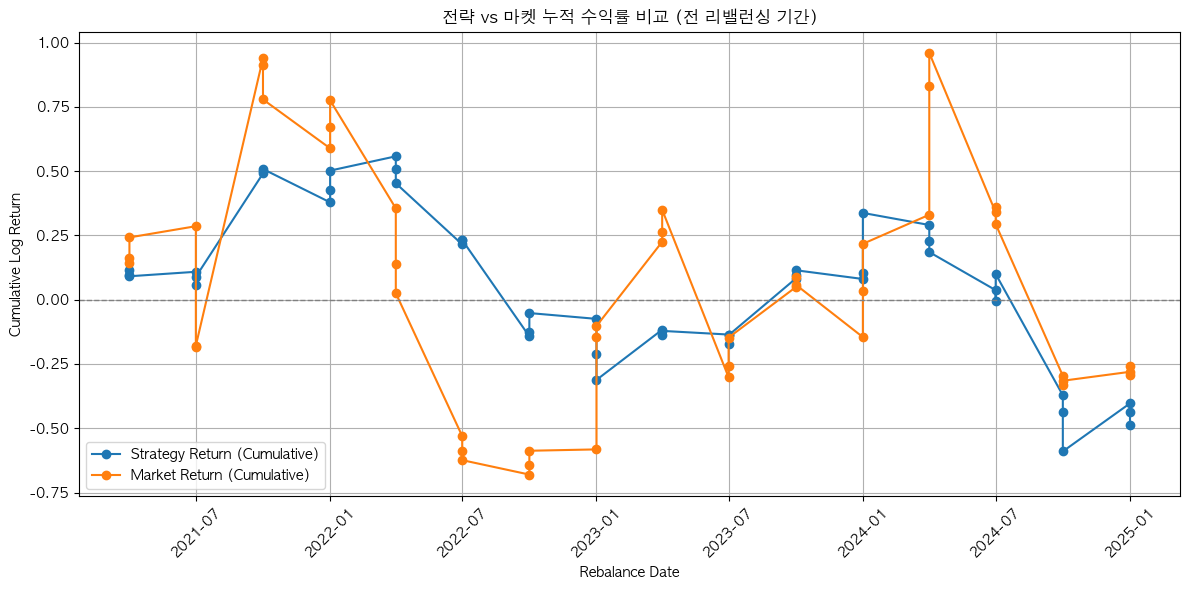

In [6]:
import matplotlib.pyplot as plt

# 누적 수익률 계산
rebalance_results_df['cum_strategy_return'] = rebalance_results_df['strategy_return'].cumsum()
rebalance_results_df['cum_market_return'] = rebalance_results_df['market_return'].cumsum()

# 시각화
plt.figure(figsize=(12, 6))
plt.plot(rebalance_results_df['rebalance_date'], rebalance_results_df['cum_strategy_return'], label='Strategy Return (Cumulative)', marker='o')
plt.plot(rebalance_results_df['rebalance_date'], rebalance_results_df['cum_market_return'], label='Market Return (Cumulative)', marker='o')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Rebalance Date')
plt.ylabel('Cumulative Log Return')
plt.title('전략 vs 마켓 누적 수익률 비교 (전 리밸런싱 기간)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [9]:
rebalance_results_df['alpha'] = rebalance_results_df['strategy_return'] - rebalance_results_df['market_return']
rebalance_results_df

,rebalance_date,industry,threshold,strategy_return,market_return,hit_rate,cum_strategy_return,cum_market_return,alpha
0,2021-04-01,보험업,0.2,0.097700,0.142610,0.862857,0.097700,0.142610,-0.044909
1,2021-04-01,전자부품,0.2,0.017118,0.018788,0.703654,0.114818,0.161398,-0.001670
2,2021-04-01,금융업,0.4,-0.023742,0.080745,0.936364,0.091077,0.242142,-0.104486
3,2021-07-01,보험업,0.2,0.017429,0.043591,0.900000,0.108505,0.285734,-0.026163
4,2021-07-01,전자부품,0.2,-0.050086,-0.471320,0.665861,0.058420,-0.185587,0.421234
5,2021-07-01,금융업,0.4,0.030503,0.006612,0.957143,0.088923,-0.178974,0.023891
6,2021-10-01,전자부품,0.2,0.401826,1.117478,0.705769,0.490749,0.938504,-0.715651
7,2021-10-01,금융업,0.4,0.009058,-0.027498,0.969492,0.499807,0.911006,0.036555
8,2021-10-01,보험업,0.2,0.008222,-0.132405,0.918841,0.508028,0.778601,0.140627
9,2022-01-01,전자부품,0.2,-0.129616,-0.190205,0.630857,0.378412,0.588396,0.060589


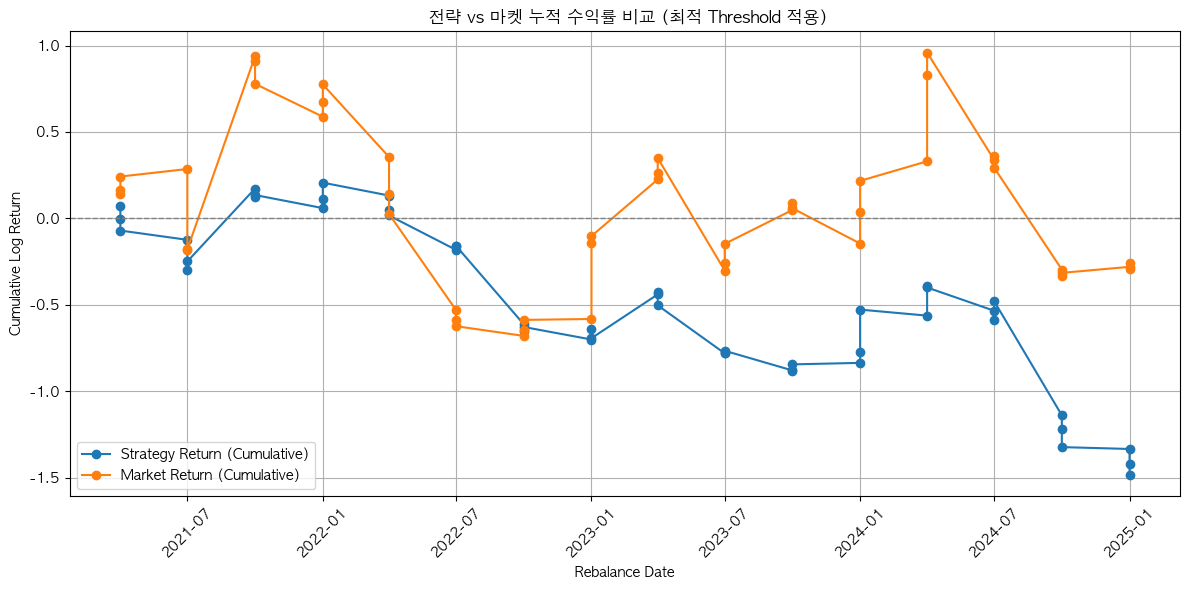

In [12]:

optimal_buy_data = {
    '항공운송': 0.1, '전자부품': 0.1, '바이오': 0.3, '에너지': 0.1, '조선업': 0.1,
    '금속제조업': 0.1, '반도체제조업': 0.4, '자동차': 0.1, '정보통신업': 0.3, '건설업': 0.3,
    '석유정제': 0.4, '금융업': 0.2, '보험업': 0.3, '식료품': 0.3, '방송업': 0.1
}

# 리밸런싱 전략 재실행
rebalance_results = []

for rebalance_date in rebalance_dates:
    lookback_start = rebalance_date - pd.DateOffset(months=3)
    past_df = df[(df['adjusted_date'] >= lookback_start) & (df['adjusted_date'] <= rebalance_date)].copy()

    scores = []
    for industry, weights in manual_weights.items():
        sub = past_df[past_df['industry'] == industry].dropna(subset=weights.keys())
        if sub.empty:
            continue
        sub['manual_score'] = sum(sub[feat] * w for feat, w in weights.items())
        mean_score = sub['manual_score'].mean()
        scores.append((industry, mean_score))
    
    top_industries = sorted(scores, key=lambda x: x[1], reverse=True)[:top_n]
    selected_industries = [x[0] for x in top_industries]

    hold_start = rebalance_date + timedelta(days=1)
    hold_end = hold_start + pd.DateOffset(months=hold_months)
    hold_df = df[(df['adjusted_date'] >= hold_start) & (df['adjusted_date'] < hold_end)]
    hold_df = hold_df[hold_df['industry'].isin(selected_industries)]

    for industry in selected_industries:
        if industry not in optimal_buy_data:
            continue

        weights = manual_weights[industry]
        t_shift = get_t_shift(industry)
        sub = df[df['industry'] == industry].copy().dropna(subset=weights.keys())
        sub['future_close'] = sub['industry_avg_close'].shift(-t_shift)
        sub['log_return'] = np.log(sub['future_close'] / sub['industry_avg_close'])
        sub['manual_score'] = sum(sub[feat] * w for feat, w in weights.items())
        sub = sub.dropna(subset=['manual_score', 'log_return'])

        train = sub[sub['adjusted_date'] < hold_start]
        test = sub[(sub['adjusted_date'] >= hold_start) & (sub['adjusted_date'] < hold_end)]
        if train.empty or test.empty:
            continue

        X_train = train[list(weights.keys())]
        y_train = (train['log_return'] > 0.01).astype(int)
        X_test = test[list(weights.keys())]
        model = get_model(industry, y_train)
        model.fit(X_train, y_train)
        proba = model.predict_proba(X_test)[:, 1]
        threshold = optimal_buy_data[industry]
        test['pred'] = (proba > threshold).astype(int)
        test['strategy_return'] = test['log_return'] * test['pred']

        rebalance_results.append({
            'rebalance_date': rebalance_date,
            'industry': industry,
            'threshold': threshold,
            'strategy_return': test['strategy_return'].sum(),
            'market_return': test['log_return'].sum(),
            'hit_rate': (test['pred'] == (test['log_return'] > 0.01).astype(int)).mean()
        })

# 누적 수익률 시각화
rebalance_results_df = pd.DataFrame(rebalance_results)
rebalance_results_df['cum_strategy_return'] = rebalance_results_df['strategy_return'].cumsum()
rebalance_results_df['cum_market_return'] = rebalance_results_df['market_return'].cumsum()

plt.figure(figsize=(12, 6))
plt.plot(rebalance_results_df['rebalance_date'], rebalance_results_df['cum_strategy_return'], label='Strategy Return (Cumulative)', marker='o')
plt.plot(rebalance_results_df['rebalance_date'], rebalance_results_df['cum_market_return'], label='Market Return (Cumulative)', marker='o')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Rebalance Date')
plt.ylabel('Cumulative Log Return')
plt.title(' 전략 vs 마켓 누적 수익률 비교 (최적 Threshold 적용)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


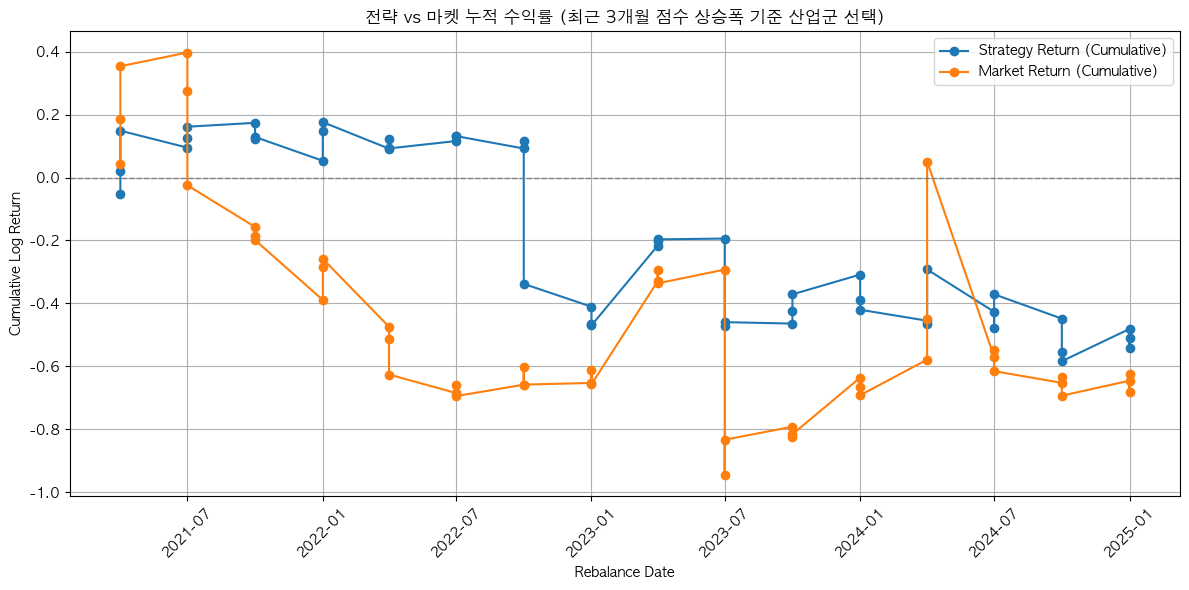

In [14]:
# 최근 3개월 동안 manual_score의 상승폭이 큰 산업군을 우선 선택

rebalance_results = []

for rebalance_date in rebalance_dates:
    lookback_start = rebalance_date - pd.DateOffset(months=3)
    past_df = df[(df['adjusted_date'] >= lookback_start) & (df['adjusted_date'] <= rebalance_date)].copy()

    scores = []
    for industry, weights in manual_weights.items():
        sub = past_df[past_df['industry'] == industry].dropna(subset=weights.keys())
        if len(sub) < 2:
            continue
        sub['manual_score'] = sum(sub[feat] * w for feat, w in weights.items())
        score_change = sub['manual_score'].iloc[-1] - sub['manual_score'].iloc[0]
        scores.append((industry, score_change))

    # 최근 3개월간 manual_score 상승폭 기준으로 정렬
    top_industries = sorted(scores, key=lambda x: x[1], reverse=True)[:top_n]
    selected_industries = [x[0] for x in top_industries]

    hold_start = rebalance_date + timedelta(days=1)
    hold_end = hold_start + pd.DateOffset(months=hold_months)
    hold_df = df[(df['adjusted_date'] >= hold_start) & (df['adjusted_date'] < hold_end)]
    hold_df = hold_df[hold_df['industry'].isin(selected_industries)]

    for industry in selected_industries:
        if industry not in optimal_buy_data:
            continue

        weights = manual_weights[industry]
        t_shift = get_t_shift(industry)
        sub = df[df['industry'] == industry].copy().dropna(subset=weights.keys())
        sub['future_close'] = sub['industry_avg_close'].shift(-t_shift)
        sub['log_return'] = np.log(sub['future_close'] / sub['industry_avg_close'])
        sub['manual_score'] = sum(sub[feat] * w for feat, w in weights.items())
        sub = sub.dropna(subset=['manual_score', 'log_return'])

        train = sub[sub['adjusted_date'] < hold_start]
        test = sub[(sub['adjusted_date'] >= hold_start) & (sub['adjusted_date'] < hold_end)]
        if train.empty or test.empty:
            continue

        X_train = train[list(weights.keys())]
        y_train = (train['log_return'] > 0.01).astype(int)
        X_test = test[list(weights.keys())]
        model = get_model(industry, y_train)
        model.fit(X_train, y_train)
        proba = model.predict_proba(X_test)[:, 1]
        threshold = optimal_buy_data[industry]
        test['pred'] = (proba > threshold).astype(int)
        test['strategy_return'] = test['log_return'] * test['pred']

        rebalance_results.append({
            'rebalance_date': rebalance_date,
            'industry': industry,
            'threshold': threshold,
            'strategy_return': test['strategy_return'].sum(),
            'market_return': test['log_return'].sum(),
            'hit_rate': (test['pred'] == (test['log_return'] > 0.01).astype(int)).mean()
        })

# 누적 수익률 그래프
rebalance_results_df = pd.DataFrame(rebalance_results)
rebalance_results_df['cum_strategy_return'] = rebalance_results_df['strategy_return'].cumsum()
rebalance_results_df['cum_market_return'] = rebalance_results_df['market_return'].cumsum()

plt.figure(figsize=(12, 6))
plt.plot(rebalance_results_df['rebalance_date'], rebalance_results_df['cum_strategy_return'], label='Strategy Return (Cumulative)', marker='o')
plt.plot(rebalance_results_df['rebalance_date'], rebalance_results_df['cum_market_return'], label='Market Return (Cumulative)', marker='o')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Rebalance Date')
plt.ylabel('Cumulative Log Return')
plt.title('전략 vs 마켓 누적 수익률 (최근 3개월 점수 상승폭 기준 산업군 선택)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [16]:
industry_selection_log = rebalance_results_df.groupby('rebalance_date')['industry'].apply(list).reset_index()
industry_selection_log.columns = ['rebalance_date', 'selected_industries']
industry_selection_log


,rebalance_date,selected_industries
0,2021-04-01,"[식료품, 보험업, 조선업]"
1,2021-07-01,"[보험업, 식료품, 정보통신업]"
2,2021-10-01,"[보험업, 금융업, 식료품]"
3,2022-01-01,"[전자부품, 보험업, 식료품]"
4,2022-04-01,"[금융업, 식료품, 보험업]"
5,2022-07-01,"[금융업, 식료품, 보험업]"
6,2022-10-01,"[금융업, 보험업, 전자부품]"
7,2023-01-01,"[금융업, 보험업, 식료품]"
8,2023-04-01,"[전자부품, 금융업, 식료품]"
9,2023-07-01,"[금융업, 전자부품, 보험업]"
